In [1]:
import pandas as pd
import numpy as np

import sys
sys.path.append('..')

# Loading Data

In [2]:
clus_id = 4

In [3]:
labels = pd.read_csv(f"../data_in_processing/cluster_outputs/labels_{clus_id}.csv", index_col=[0, 1, 2, 3, 4, 5, 6])

labels

label
image_T track_id_t0 track_id_t1 track_id_t2 track_id_t3 track_id_t4 track_id_t5       
0       762         1316        1300        1264        1300        1272            -1
        1419        1316        1300        1264        1300        1272            -1
        1019        1316        1300        1264        1300        1272            -1
        1419        1316        1300        762         1300        1272            -1
        762         1316        1300        762         1300        1272            -1
...                                                                                ...
251     72          2475        1004        399         1052        1117            -1
        283         72          2475        1004        1052        1117            -1
        1114        72          1053        1004        1052        1117            -1
                    283         72          2475        1052        1117            -1
                    72          1053        1004        399         1117            -1

[869003 rows x 1 columns]

In [4]:
df_top_5 = pd.read_parquet(f"../data_in_processing/data_top5std.parquet")

df_top_5 = df_top_5.set_index(["image_T"] + [f"track_id_t{i}" for i in range(5+1)])

df_top_5

ERK_diff_t0  \
image_T track_id_t0 track_id_t1 track_id_t2 track_id_t3 track_id_t4 track_id_t5                
0       762         1316        1300        1264        1300        1272           -1.000000   
        1264        1316        1300        1264        1300        1272           -1.000000   
        1419        1316        1300        1264        1300        1272           -1.000000   
        1300        1316        1300        1264        1300        1272           -1.000000   
        1019        1316        1300        1264        1300        1272           -1.000000   
...                                                                                      ...   
251     1114        72          1053        1004        1052        1117            0.006720   
        283         72          1053        1004        1052        1117            0.006720   
        1114        283         72          2475        1052        1117           -0.006981   
                    72          2475        1004        399         1117            0.006720   
                                1053        1004        399         1117            0.006720   

                                                                                 ERK_diff_t1  \
image_T track_id_t0 track_id_t1 track_id_t2 track_id_t3 track_id_t4 track_id_t5                
0       762         1316        1300        1264        1300        1272            0.786236   
        1264        1316        1300        1264        1300        1272            0.786236   
        1419        1316        1300        1264        1300        1272            0.786236   
        1300        1316        1300        1264        1300        1272            0.786236   
        1019        1316        1300        1264        1300        1272            0.786236   
...                                                                                      ...   
251     1114        72          1053        1004        1052        1117            0.026285   
        283         72          1053        1004        1052        1117            0.026285   
        1114        283         72          2475        1052        1117           -0.006943   
                    72          2475        1004        399         1117            0.017854   
                                1053        1004        399         1117            0.026285   

                                                                                 ERK_diff_t2  \
image_T track_id_t0 track_id_t1 track_id_t2 track_id_t3 track_id_t4 track_id_t5                
0       762         1316        1300        1264        1300        1272           -0.004751   
        1264        1316        1300        1264        1300        1272           -0.004751   
        1419        1316        1300        1264        1300        1272           -0.004751   
        1300        1316        1300        1264        1300        1272           -0.004751   
        1019        1316        1300        1264        1300        1272           -0.004751   
...                                                                                      ...   
251     1114        72          1053        1004        1052        1117           -0.027770   
        283         72          1053        1004        1052        1117           -0.027770   
        1114        283         72          2475        1052        1117            0.011757   
                    72          2475        1004        399         1117           -0.027770   
                                1053        1004        399         1117           -0.027770   

                                                                                 ERK_diff_t3  \
image_T track_id_t0 track_id_t1 track_id_t2 track_id_t3 track_id_t4 track_id_t5                
0       762         1316        1300        1264        1300        1272           -0.703872   
        1264        1316        1300        12

In [5]:
df = df_top_5.loc[::2]

df["label"] = labels["label"]

df

ERK_diff_t0  \
image_T track_id_t0 track_id_t1 track_id_t2 track_id_t3 track_id_t4 track_id_t5                
0       762         1316        1300        1264        1300        1272           -1.000000   
        1419        1316        1300        1264        1300        1272           -1.000000   
        1019        1316        1300        1264        1300        1272           -1.000000   
        1419        1316        1300        762         1300        1272           -1.000000   
        762         1316        1300        762         1300        1272           -1.000000   
...                                                                                      ...   
251     72          2475        1004        399         1052        1117            0.007409   
        283         72          2475        1004        1052        1117            0.006720   
        1114        72          1053        1004        1052        1117            0.006720   
                    283         72          2475        1052        1117           -0.006981   
                    72          1053        1004        399         1117            0.006720   

                                                                                 ERK_diff_t1  \
image_T track_id_t0 track_id_t1 track_id_t2 track_id_t3 track_id_t4 track_id_t5                
0       762         1316        1300        1264        1300        1272            0.786236   
        1419        1316        1300        1264        1300        1272            0.786236   
        1019        1316        1300        1264        1300        1272            0.786236   
        1419        1316        1300        762         1300        1272            0.786236   
        762         1316        1300        762         1300        1272            0.786236   
...                                                                                      ...   
251     72          2475        1004        399         1052        1117           -0.022419   
        283         72          2475        1004        1052        1117            0.017854   
        1114        72          1053        1004        1052        1117            0.026285   
                    283         72          2475        1052        1117           -0.006943   
                    72          1053        1004        399         1117            0.026285   

                                                                                 ERK_diff_t2  \
image_T track_id_t0 track_id_t1 track_id_t2 track_id_t3 track_id_t4 track_id_t5                
0       762         1316        1300        1264        1300        1272           -0.004751   
        1419        1316        1300        1264        1300        1272           -0.004751   
        1019        1316        1300        1264        1300        1272           -0.004751   
        1419        1316        1300        762         1300        1272           -0.011782   
        762         1316        1300        762         1300        1272           -0.011782   
...                                                                                      ...   
251     72          2475        1004        399         1052        1117           -0.003896   
        283         72          2475        1004        1052        1117           -0.027770   
        1114        72          1053        1004        1052        1117           -0.027770   
                    283         72          2475        1052        1117            0.011757   
                    72          1053        1004        399         1117           -0.027770   

                                                                                 ERK_diff_t3  \
image_T track_id_t0 track_id_t1 track_id_t2 track_id_t3 track_id_t4 track_id_t5                
0       762         1316        1300        1264        1300        1272           -0.703872   
        1419        1316        1300        12

# Visualizing Data

In [6]:
from scripts.Cluster_plotting import plot_all_columns

In [7]:
df["label"] == 1

image_T  track_id_t0  track_id_t1  track_id_t2  track_id_t3  track_id_t4  track_id_t5
0        762          1316         1300         1264         1300         1272           False
         1419         1316         1300         1264         1300         1272           False
         1019         1316         1300         1264         1300         1272           False
         1419         1316         1300         762          1300         1272           False
         762          1316         1300         762          1300         1272           False
                                                                                         ...  
251      72           2475         1004         399          1052         1117           False
         283          72           2475         1004         1052         1117           False
         1114         72           1053         1004         1052         1117           False
                      283          72           2475       

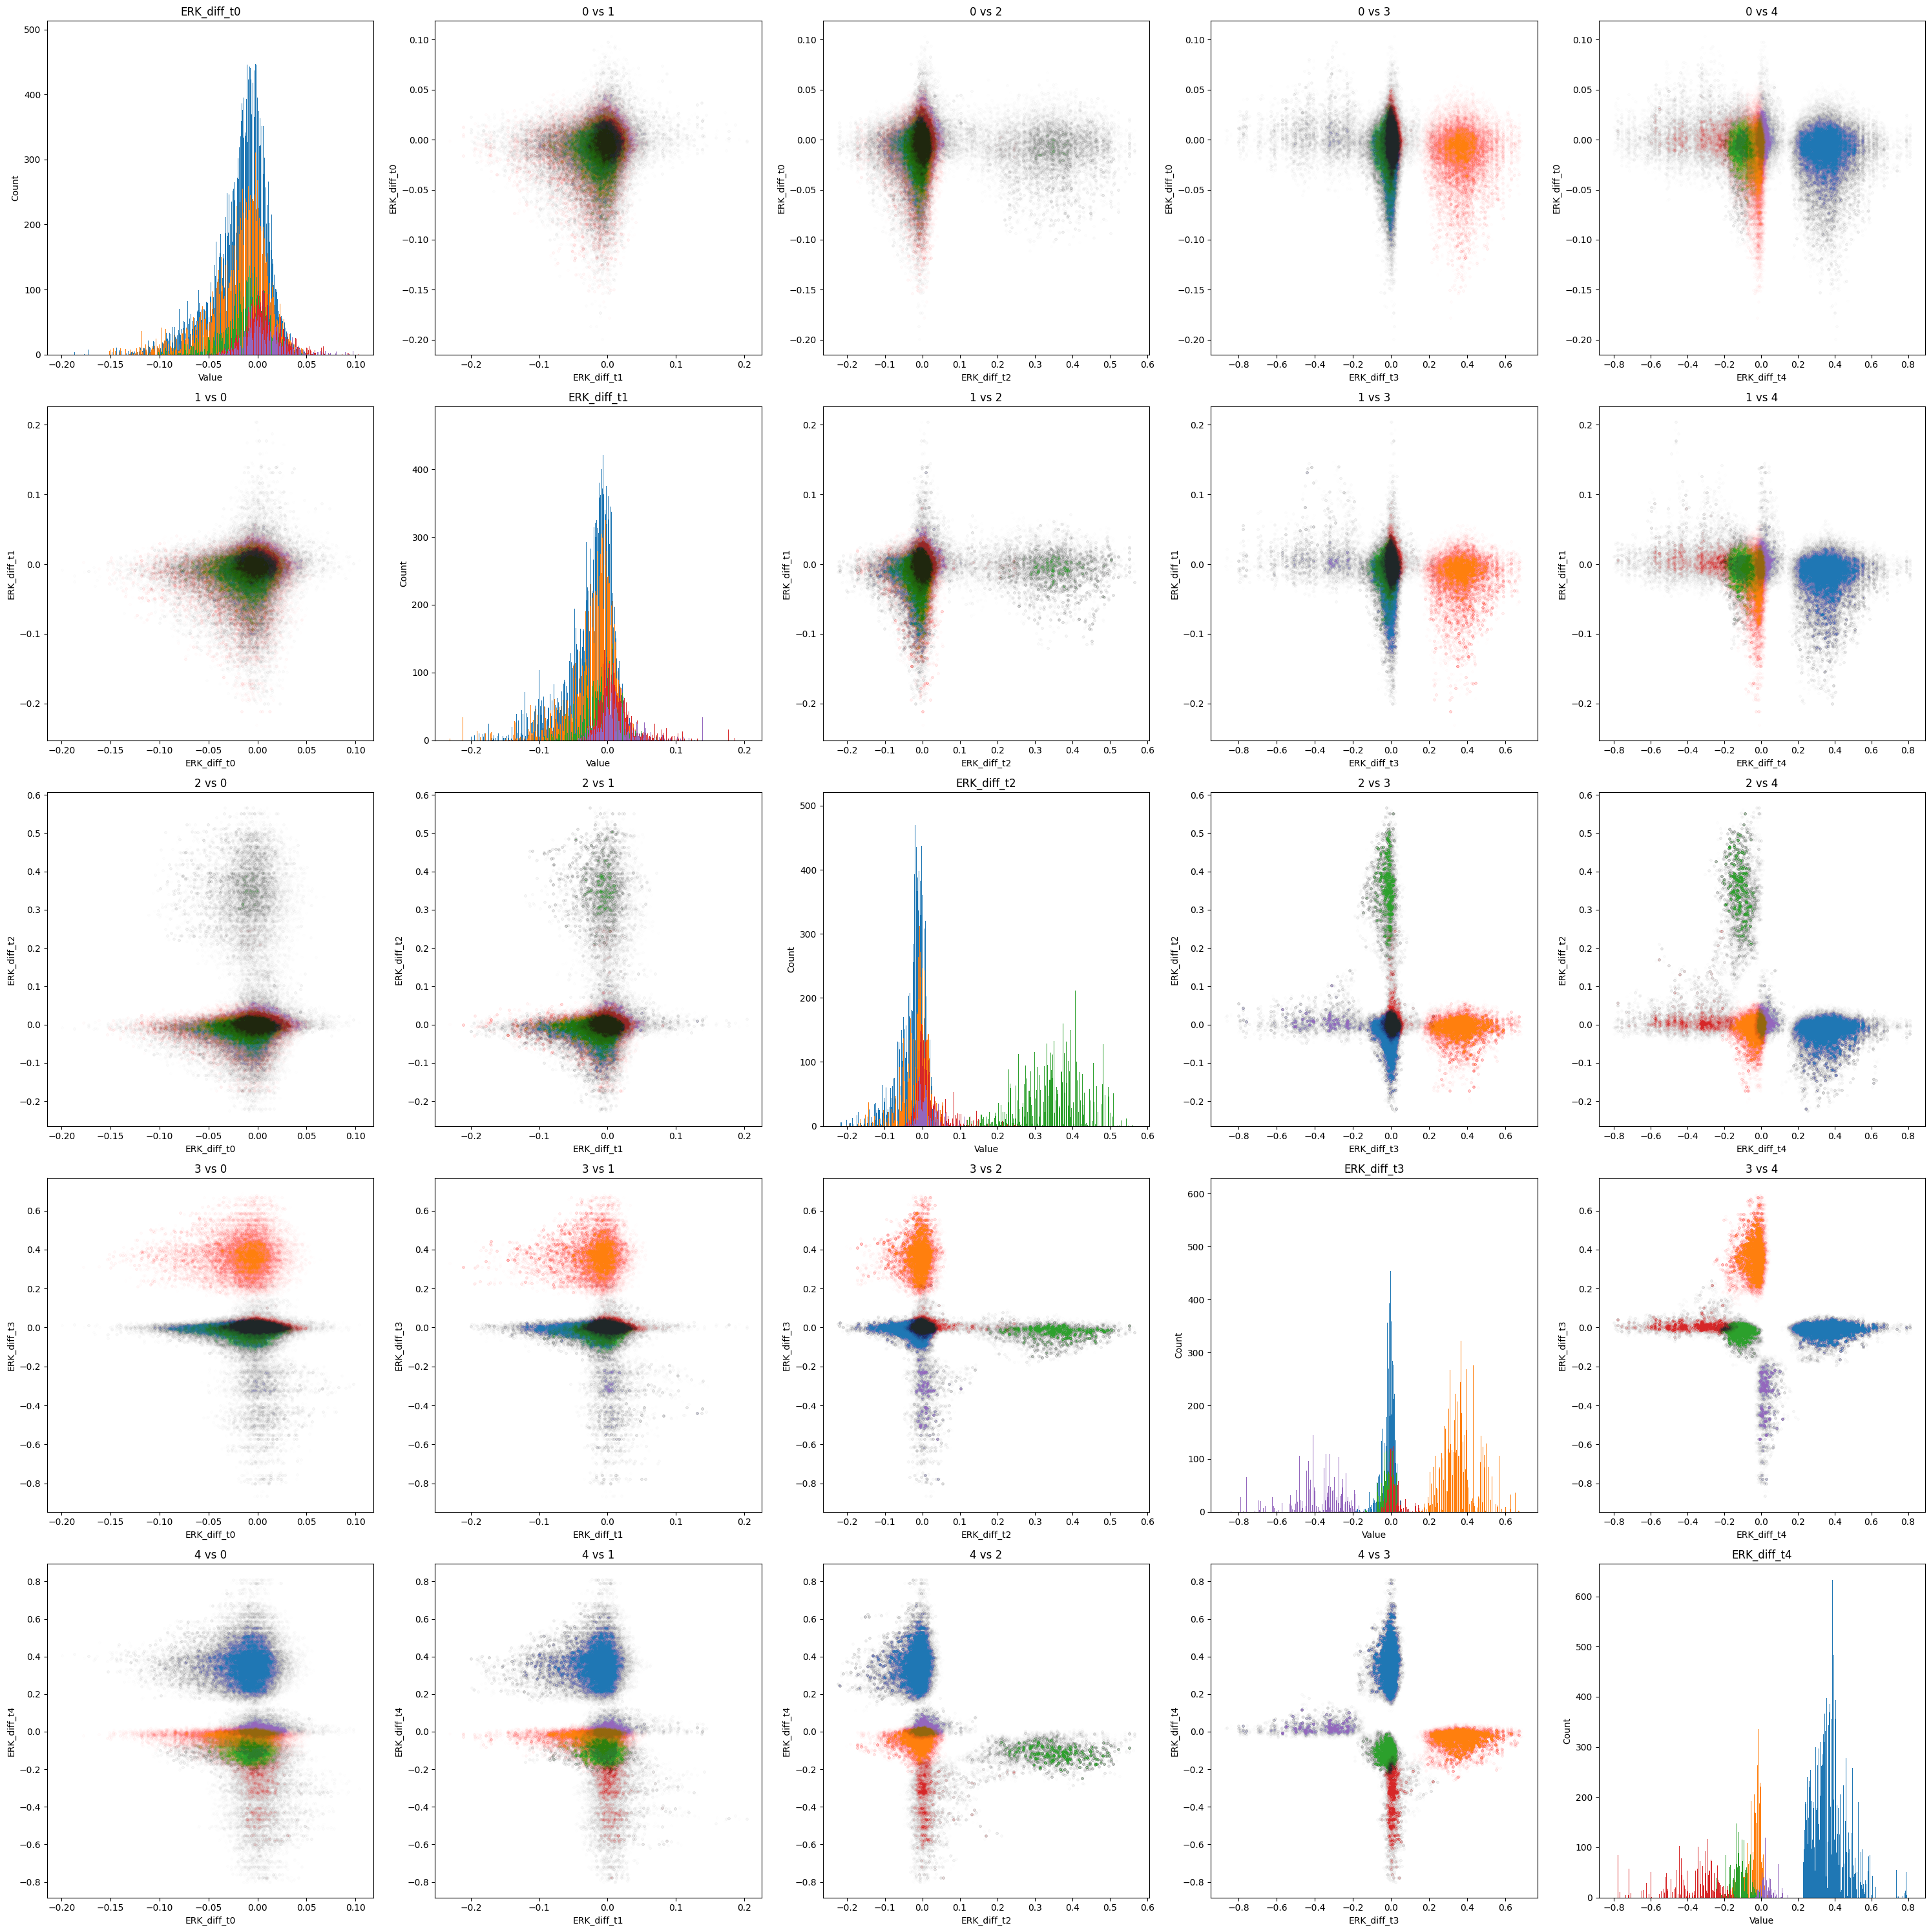

In [8]:
plot_all_columns(
    df.drop(columns="label"),
    df["label"],
    sel_labels=[lab for lab, lab_count in df["label"].value_counts().to_dict().items() if lab != -1 and lab_count>10_000],
    save_path=None
)